In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

In [4]:
matches = pd.read_csv( r"C:\Users\Teju\OneDrive\Desktop\Project\IPL-Player-Stats-EDA\data\IPL dataset\matches.csv")
print(matches.shape)
print(matches.columns.tolist())

(636, 18)
['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner', 'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2', 'umpire3']


In [21]:
matches['team1'] = matches['team1'].replace('Rising Pune Supergiant', 'Rising Pune Supergiants')
matches['team2'] = matches['team2'].replace('Rising Pune Supergiant', 'Rising Pune Supergiants')
matches['winner'] = matches['winner'].replace('Rising Pune Supergiant', 'Rising Pune Supergiants')
matches['toss_winner'] = matches['toss_winner'].replace('Rising Pune Supergiant', 'Rising Pune Supergiants')

print("Fixed team name inconsistency")

Fixed team name inconsistency


In [22]:
df = matches[matches['result'] == 'normal'].copy()
df = df[df['winner'].notna()]
df = df.sort_values('date').reset_index(drop=True)

win_counts = {}
match_counts = {}
team1_winrate = []
team2_winrate = []

for _, row in df.iterrows():
    t1 = row['team1']
    t2 = row['team2']
    winner = row['winner']
    
    t1_rate = win_counts.get(t1, 0) / match_counts.get(t1, 1)
    t2_rate = win_counts.get(t2, 0) / match_counts.get(t2, 1)
    
    team1_winrate.append(round(t1_rate, 3))
    team2_winrate.append(round(t2_rate, 3))
    
    match_counts[t1] = match_counts.get(t1, 0) + 1
    match_counts[t2] = match_counts.get(t2, 0) + 1
    win_counts[winner] = win_counts.get(winner, 0) + 1

df['team1_winrate'] = team1_winrate
df['team2_winrate'] = team2_winrate
df['team1_won_toss'] = (df['toss_winner'] == df['team1']).astype(int)

features_needed = ['team1', 'team2', 'toss_winner', 'toss_decision', 
                   'venue', 'team1_winrate', 'team2_winrate', 
                   'team1_won_toss', 'winner']
df = df[features_needed]

print(f"Dataset shape: {df.shape}")

Dataset shape: (626, 9)


In [23]:
le_team = LabelEncoder()
le_venue = LabelEncoder()
le_decision = LabelEncoder()

all_teams = pd.concat([df['team1'], df['team2'], df['toss_winner'], df['winner']]).unique()
le_team.fit(all_teams)
le_venue.fit(df['venue'])
le_decision.fit(df['toss_decision'])

df['team1_enc'] = le_team.transform(df['team1'])
df['team2_enc'] = le_team.transform(df['team2'])
df['toss_winner_enc'] = le_team.transform(df['toss_winner'])
df['toss_decision_enc'] = le_decision.transform(df['toss_decision'])
df['venue_enc'] = le_venue.transform(df['venue'])
df['winner_enc'] = le_team.transform(df['winner'])

print(df.columns.tolist())

['team1', 'team2', 'toss_winner', 'toss_decision', 'venue', 'team1_winrate', 'team2_winrate', 'team1_won_toss', 'winner', 'team1_enc', 'team2_enc', 'toss_winner_enc', 'toss_decision_enc', 'venue_enc', 'winner_enc']


In [24]:
X = df[['team1_enc', 'team2_enc', 'toss_winner_enc', 'toss_decision_enc', 
        'venue_enc', 'team1_winrate', 'team2_winrate', 'team1_won_toss']]
y = df['winner_enc']

print(f"Features shape: {X.shape}")

Features shape: (626, 8)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Training matches: {X_train.shape[0]}")
print(f"Testing matches: {X_test.shape[0]}")

Training matches: 500
Testing matches: 126


In [26]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
model.fit(X_train, y_train)
print("Model trained!")

Model trained!


In [27]:
y_pred = model.predict(X_test)
print("Predictions made!")

Predictions made!


In [28]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 56.35%


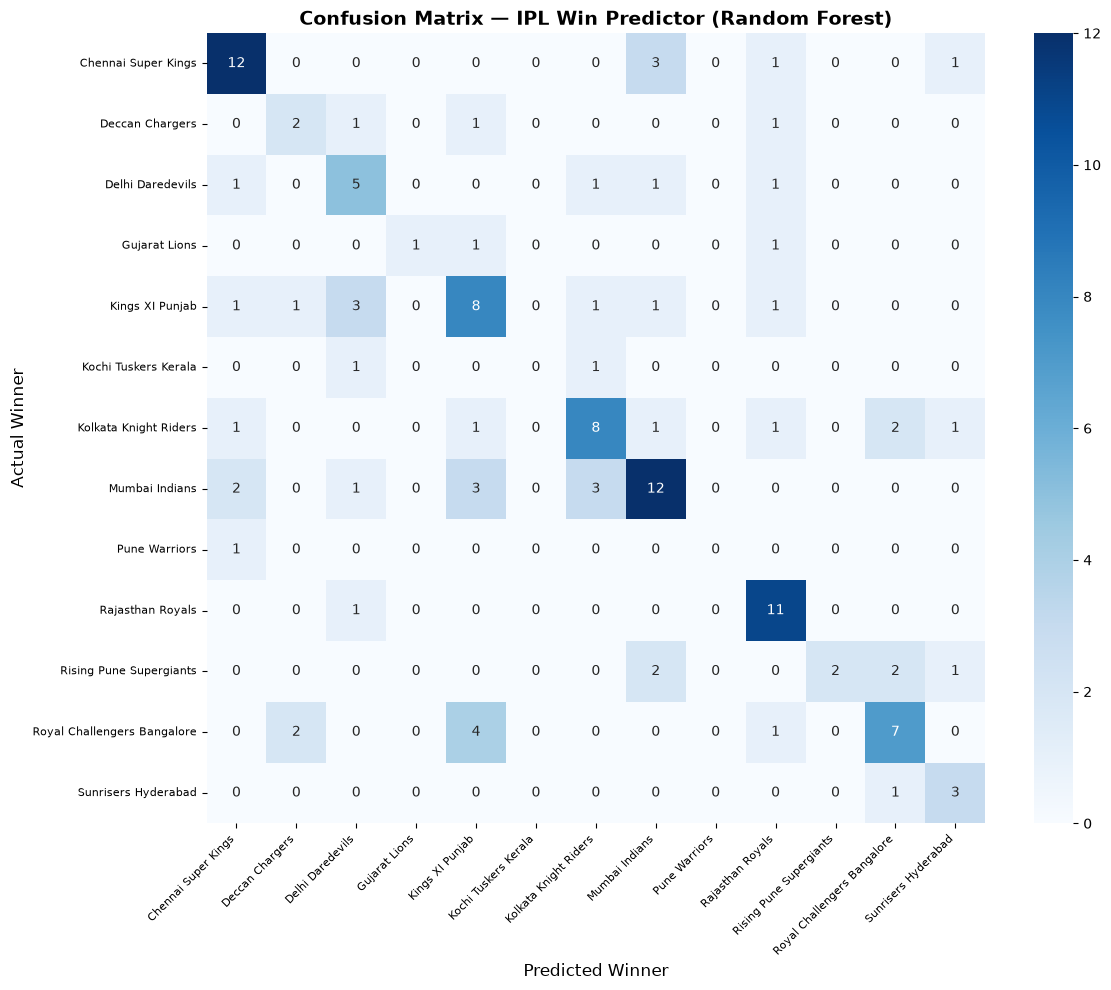

In [29]:
cm = confusion_matrix(y_test, y_pred)
labels_in_test = sorted(set(y_test) | set(y_pred))
team_names_in_test = le_team.inverse_transform(labels_in_test)

plt.figure(figsize=(12, 10))
sns.heatmap(cm,
            xticklabels=team_names_in_test,
            yticklabels=team_names_in_test,
            cmap='Blues',
            annot=True,
            fmt='d')
plt.title('Confusion Matrix — IPL Win Predictor (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Winner', fontsize=12)
plt.ylabel('Actual Winner', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [30]:
print(classification_report(y_test, y_pred, 
                             labels=labels_in_test,
                             target_names=team_names_in_test))

                             precision    recall  f1-score   support

        Chennai Super Kings       0.67      0.71      0.69        17
            Deccan Chargers       0.40      0.40      0.40         5
           Delhi Daredevils       0.42      0.56      0.48         9
              Gujarat Lions       1.00      0.33      0.50         3
            Kings XI Punjab       0.44      0.50      0.47        16
       Kochi Tuskers Kerala       0.00      0.00      0.00         2
      Kolkata Knight Riders       0.57      0.53      0.55        15
             Mumbai Indians       0.60      0.57      0.59        21
              Pune Warriors       0.00      0.00      0.00         1
           Rajasthan Royals       0.61      0.92      0.73        12
    Rising Pune Supergiants       1.00      0.29      0.44         7
Royal Challengers Bangalore       0.58      0.50      0.54        14
        Sunrisers Hyderabad       0.50      0.75      0.60         4

                   accuracy     

In [31]:
def predict_winner(team1, team2, venue, toss_winner, toss_decision):
    t1 = le_team.transform([team1])[0]
    t2 = le_team.transform([team2])[0]
    tw = le_team.transform([toss_winner])[0]
    td = le_decision.transform([toss_decision])[0]
    v  = le_venue.transform([venue])[0]
    
    t1_rate = df[df['team1_enc'] == t1]['team1_winrate'].mean()
    t2_rate = df[df['team2_enc'] == t2]['team2_winrate'].mean()
    t1_won_toss = 1 if toss_winner == team1 else 0
    
    input_data = pd.DataFrame([[t1, t2, tw, td, v, t1_rate, t2_rate, t1_won_toss]],
                   columns=['team1_enc', 'team2_enc', 'toss_winner_enc',
                            'toss_decision_enc', 'venue_enc', 
                            'team1_winrate', 'team2_winrate', 'team1_won_toss'])
    
    prediction = model.predict(input_data)[0]
    winner_name = le_team.inverse_transform([prediction])[0]
    
    proba = model.predict_proba(input_data)[0]
    confidence = round(max(proba) * 100, 1)
    
    print(f"Predicted Winner: {winner_name}")
    print(f"Confidence: {confidence}%")
    return winner_name

predict_winner(
    team1='Mumbai Indians',
    team2='Chennai Super Kings',
    venue='Wankhede Stadium',
    toss_winner='Mumbai Indians',
    toss_decision='field'
)

Predicted Winner: Mumbai Indians
Confidence: 60.8%


'Mumbai Indians'